<a href="https://colab.research.google.com/github/UtkarshSharma-004/E-Waste-Detection/blob/main/E_waste_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving E-waste_data.zip to E-waste_data.zip


In [ ]:
import os
import zipfile

zip_path = next(iter(uploaded.keys()))
extract_path = "/content/e_waste_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")
print("Extracted contents:", os.listdir(extract_path))

Dataset extracted successfully!
Extracted contents: ['modified-dataset']


In [ ]:
import os

DATA_DIR = None

for root, dirs, files_list in os.walk(extract_path):
    if all(split in dirs for split in ["train", "val", "test"]):
        DATA_DIR = root
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find train, val, and test folders."
    )

TRAIN_DIR = os.path.join(DATA_DIR, "train")
VAL_DIR = os.path.join(DATA_DIR, "val")
TEST_DIR = os.path.join(DATA_DIR, "test")

print("Dataset path:", DATA_DIR)
print("Training classes:", sorted(os.listdir(TRAIN_DIR)))
print("Validation classes:", sorted(os.listdir(VAL_DIR)))
print("Test classes:", sorted(os.listdir(TEST_DIR)))

Dataset path: /content/e_waste_dataset/modified-dataset
Training classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Validation classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']
Test classes: ['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']


In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
TRAIN_DIR = "/content/e_waste_dataset/modified-dataset/train"
VAL_DIR   = "/content/e_waste_dataset/modified-dataset/val"
TEST_DIR  = "/content/e_waste_dataset/modified-dataset/test"

In [ ]:
trainpath = TRAIN_DIR
validpath = VAL_DIR
testpath = TEST_DIR

In [ ]:
datatrain = tf.keras.utils.image_dataset_from_directory(trainpath, shuffle=True, image_size=(224, 224), batch_size=32)


Found 2400 files belonging to 10 classes.


In [ ]:
datavalid = tf.keras.utils.image_dataset_from_directory(validpath, shuffle=True, image_size=(224, 224), batch_size=32)


Found 300 files belonging to 10 classes.


In [ ]:
datatest = tf.keras.utils.image_dataset_from_directory(testpath, shuffle=False, image_size=(224, 224), batch_size=32)

Found 300 files belonging to 10 classes.


In [ ]:
print(len(datatrain.class_names))
class_names = datatrain.class_names
print(class_names)

10
['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine']


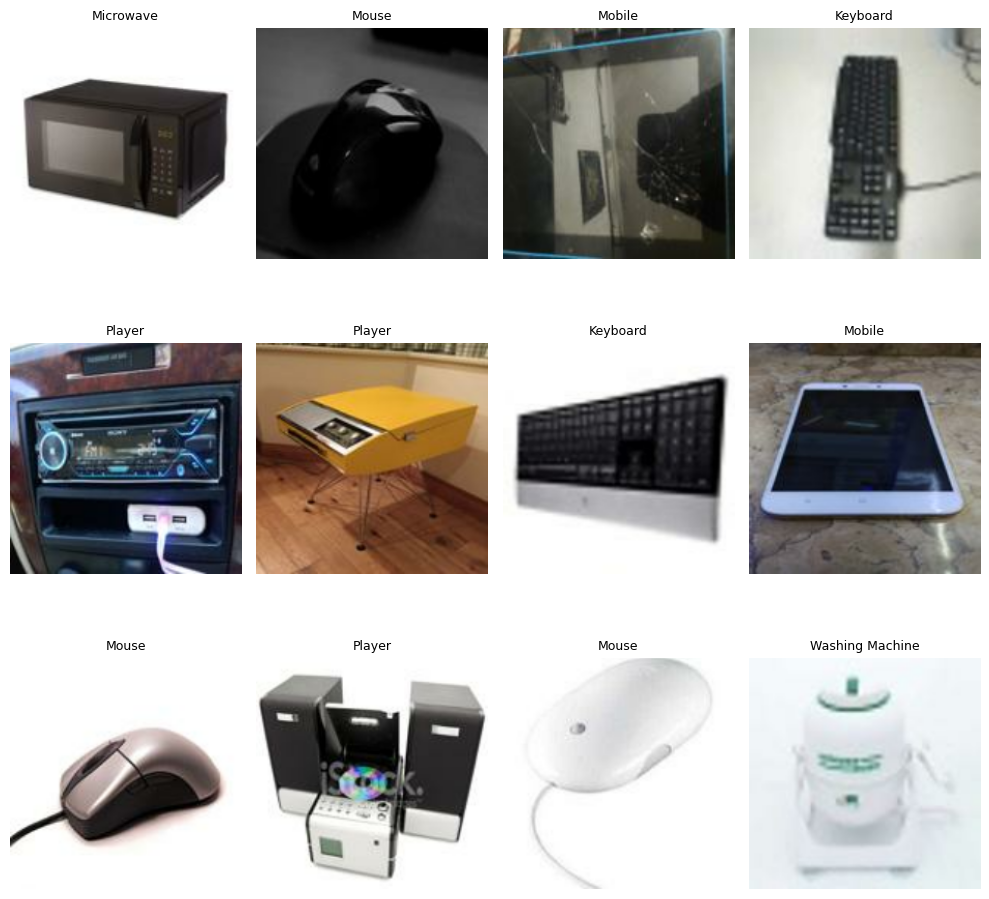

In [ ]:
def show_dataset_samples(dataset, class_names, num_images=12):

    plt.figure(figsize=(10, 10))
    rows = (num_images + 3) // 4  # Adjust rows for grid

    for images, labels in dataset.take(1):
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(rows, 4, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[labels[i]], fontsize=9)
            plt.axis("off")

    plt.tight_layout()
    plt.show()
show_dataset_samples(datatrain, class_names)

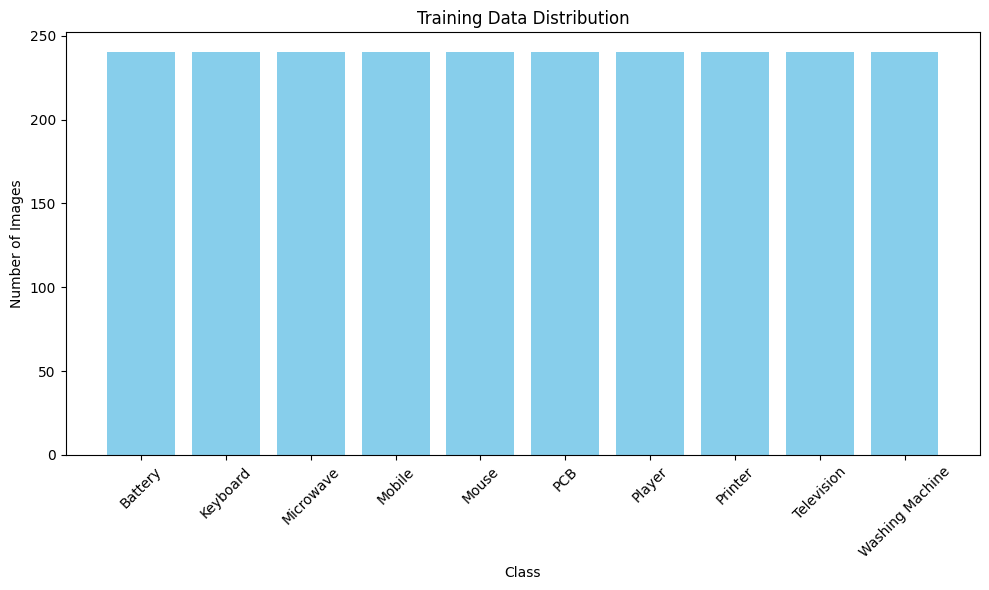

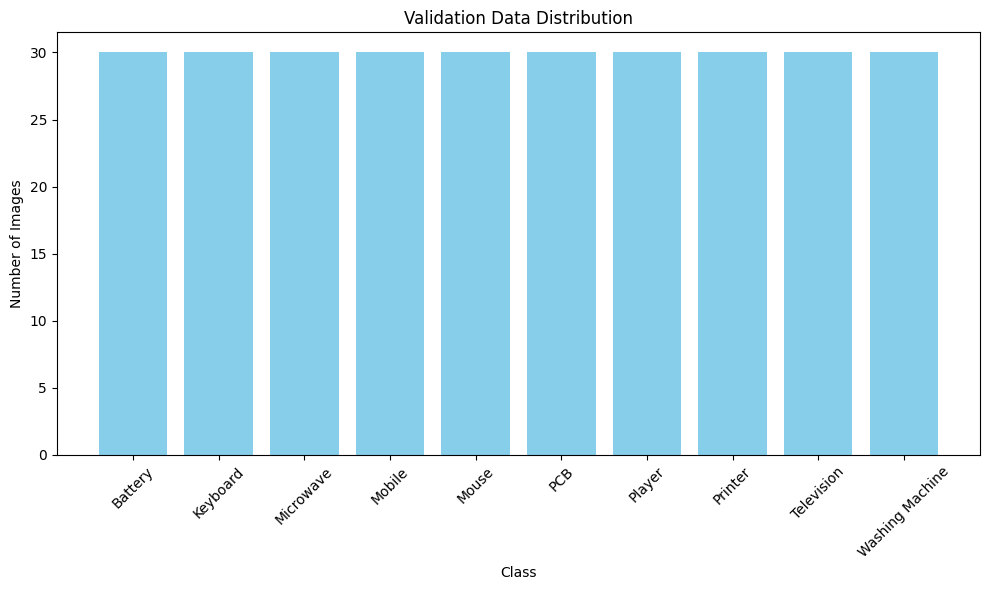

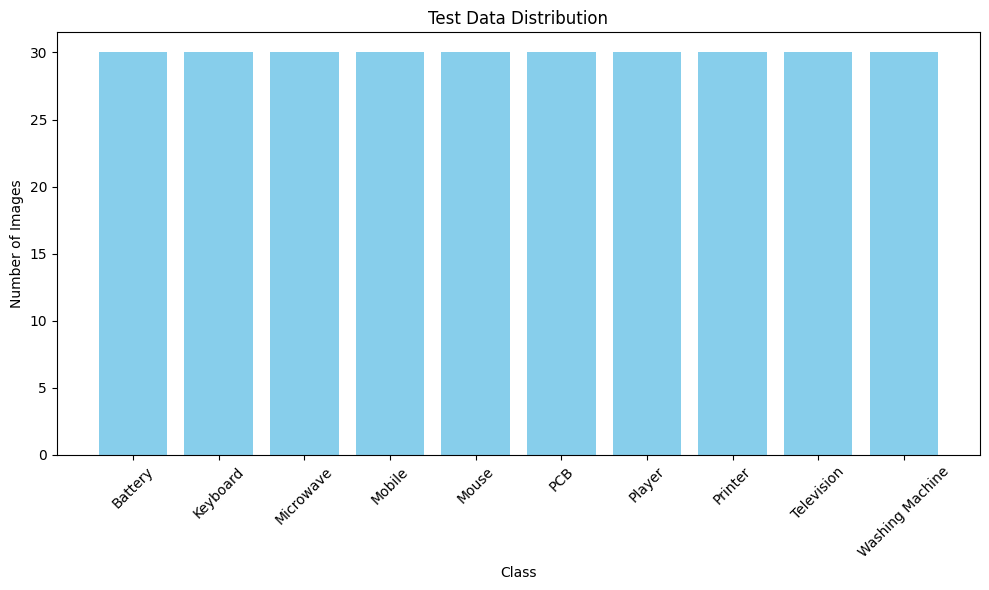

In [ ]:
def plot_class_distribution(dataset, title="Class Distribution"):
    """
    Plots the number of items per class in a given dataset.

    Args:
        dataset: A tf.data.Dataset object (e.g., datatrain, datavalid, datatest)
        title: Title for the plot (default = 'Class Distribution')
    """
    class_counts = {name: 0 for name in dataset.class_names}

    for _, labels in dataset:
        for label in labels.numpy():
            class_name = dataset.class_names[label]
            class_counts[class_name] += 1

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
plot_class_distribution(datatrain, "Training Data Distribution")
plot_class_distribution(datavalid, "Validation Data Distribution")
plot_class_distribution(datatest, "Test Data Distribution")


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(factor=0.2),
    tf.keras.layers.RandomCrop(height=224, width=224),  # Optional, adjust to your image size
    tf.keras.layers.Rescaling(1./255),  # Normalization
])

In [ ]:
# Create Model with MobileNetV3
base_model = MobileNetV3Large(include_top=False, input_shape=(224, 224, 3), weights="imagenet")
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
#TrainModel
history = model.fit(datatrain, validation_data=datavalid, epochs=10)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - accuracy: 0.8442 - loss: 0.5118 - val_accuracy: 0.9400 - val_loss: 0.1903
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9604 - loss: 0.1300 - val_accuracy: 0.9433 - val_loss: 0.1670
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9775 - loss: 0.0724 - val_accuracy: 0.9533 - val_loss: 0.1503
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.9900 - loss: 0.0408 - val_accuracy: 0.9467 - val_loss: 0.1543
Epoch 5/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9896 - loss: 0.0329 - val_accuracy: 0.9567 - val_loss: 0.1445
Epoch 6/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9975 - loss: 0.0189 - val_accuracy: 0.9600 - val_loss: 0.1281
Epoch 7/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9967 - loss: 0.0147 - val_accuracy: 0.9733 - val_loss: 0.1219
Epoch 8/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9975 - loss: 0.0110 - val_accuracy: 0.9667 -

In [ ]:

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       246,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,742,112 (14.28 MB)

 Trainable params: 248,586 (971.04 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

 Optimizer params: 497,174 (1.90 MB)

In [ ]:
base_model.summary()

Model: "MobileNetV3Large"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 112, 112,  │        432 │ rescaling_1[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 112, 112,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        144 │ activation[0][0]  │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        256 │ re_lu[0][0]       │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_add   │ (None, 112, 112,  │          0 │ activation[0][0], │
│ (Add)               │ 16)               │            │ expanded_conv_pr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │      1,024 │ expanded_conv_ad… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_ex… │ (None, 112, 112,  │        256 │ expanded_conv_1_… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 112, 112,  │          0 │ expanded_conv_1_… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 113, 113,  │          0 │ re_lu_1[0][0]     │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        576 │ expanded_conv_1_… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_1_de… │ (None, 56, 56,    │        256 │ expanded_conv_1_

 Total params: 2,996,352 (11.43 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,996,352 (11.43 MB)

In [ ]:

#Evaluation
loss, accuracy = model.evaluate(datatest)
print(f"Test Accuracy: {accuracy:.4f}, Test Loss: {loss:.4f}")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9767 - loss: 0.0798
Test Accuracy: 0.9767, Test Loss: 0.0798


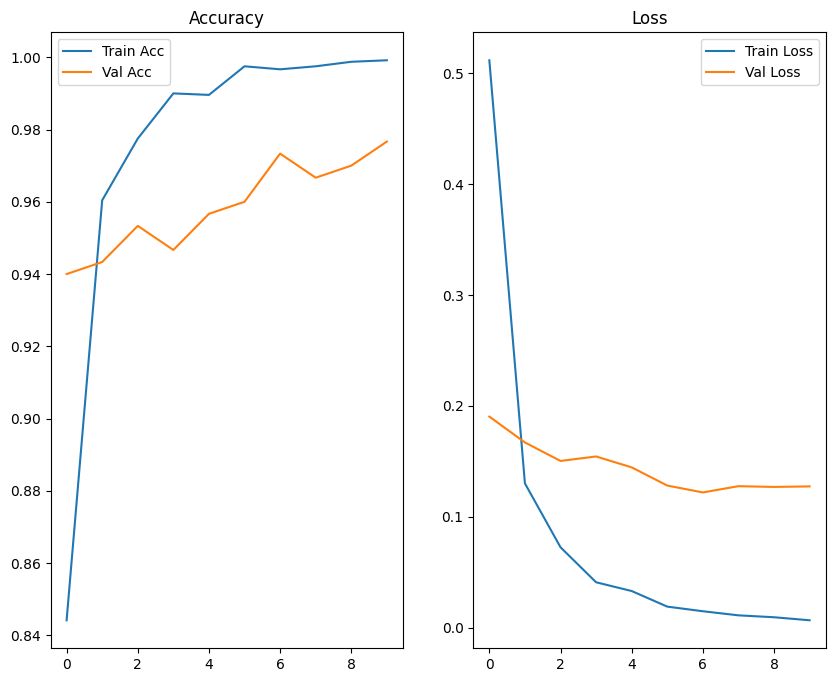

In [ ]:
# Plot Metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Acc')
plt.plot(epochs_range, val_acc, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss')
plt.plot(epochs_range, val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 515ms/step
                 precision    recall  f1-score   support

        Battery       0.97      0.97      0.97        30
       Keyboard       1.00      1.00      1.00        30
      Microwave       0.88      1.00      0.94        30
         Mobile       1.00      1.00      1.00        30
          Mouse       0.97      1.00      0.98        30
            PCB       1.00      0.97      0.98        30
         Player       0.97      0.93      0.95        30
        Printer       1.00      0.97      0.98        30
     Television       1.00      0.93      0.97        30
Washing Machine       1.00      1.00      1.00        30

       accuracy                           0.98       300
      macro avg       0.98      0.98      0.98       300
   weighted avg       0.98      0.98      0.98       300



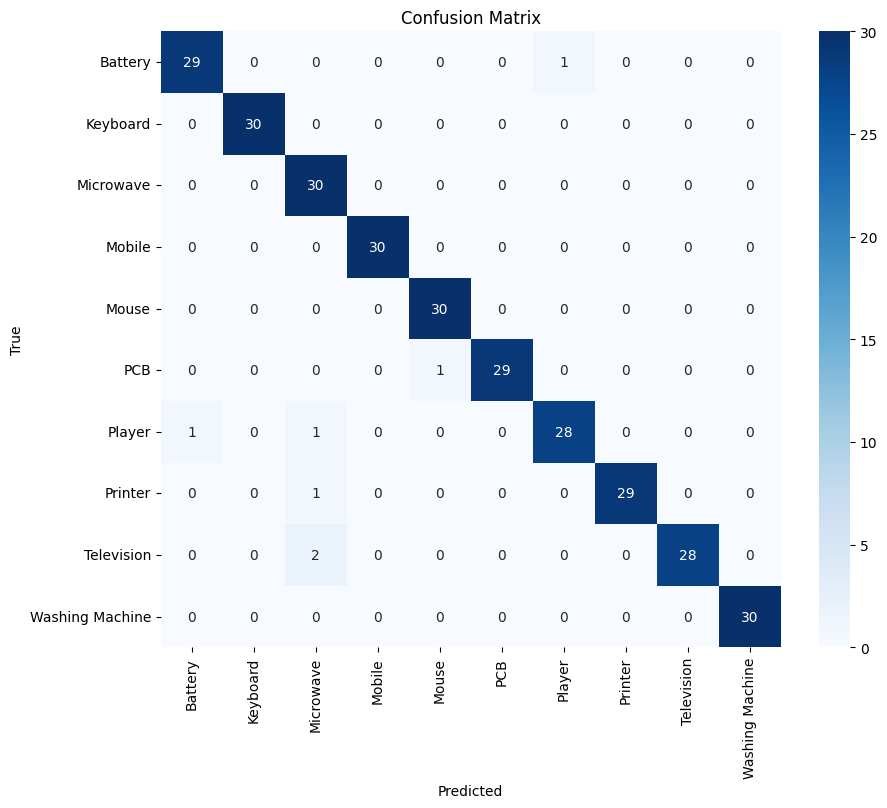

In [ ]:
# Confusion Matrix
y_true = np.concatenate([y.numpy() for x, y in datatest])
y_pred_probs = model.predict(datatest)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names))
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


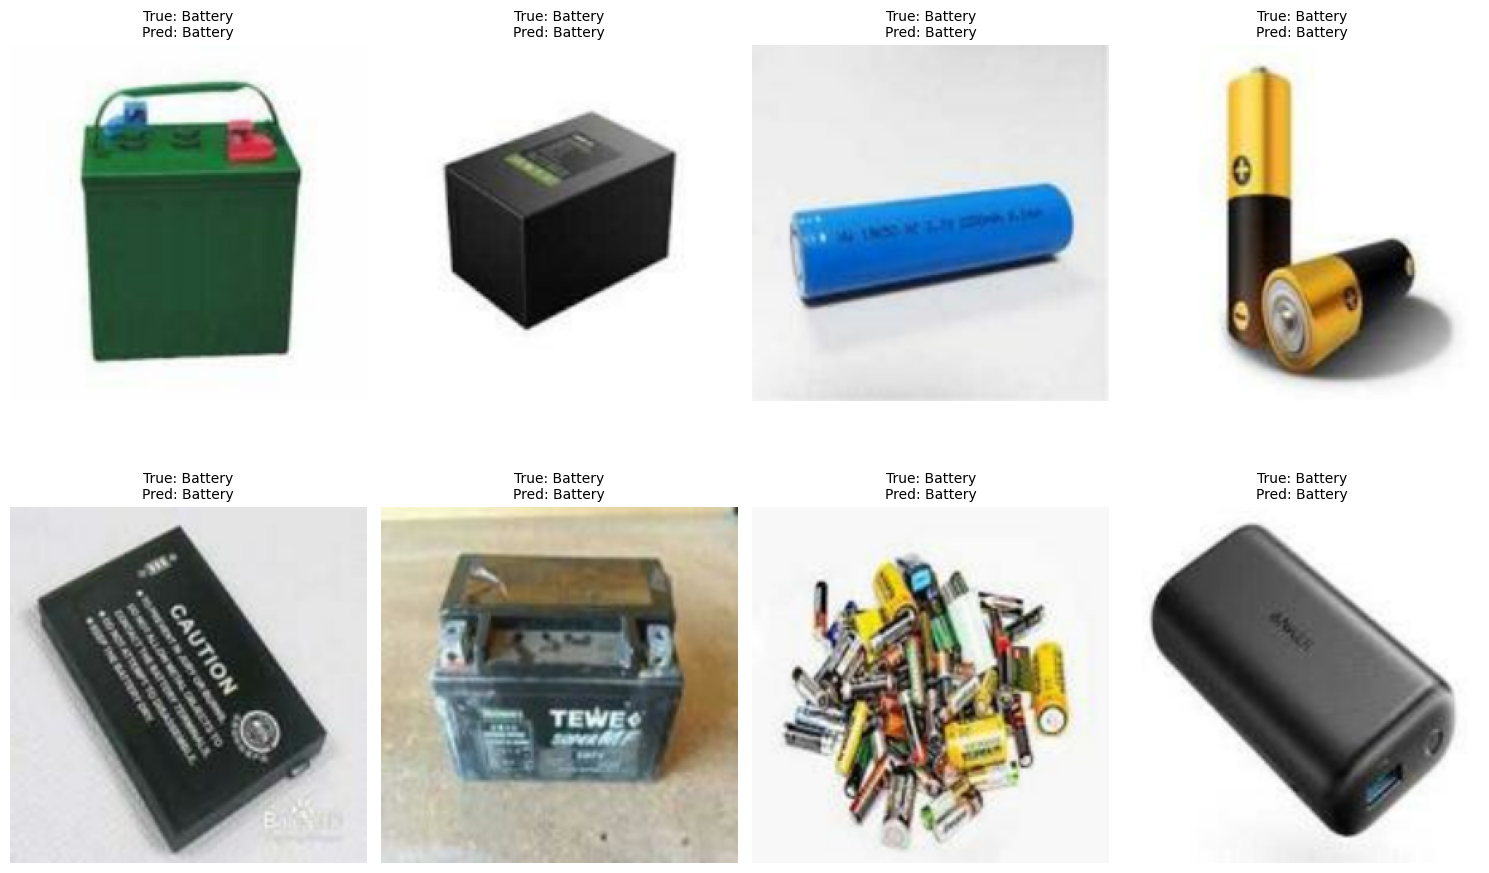

In [ ]:
def show_sample_predictions(dataset, model, class_names, num_samples=8):

    plt.figure(figsize=(15, 10))

    for images, labels in dataset.take(1):
        predictions = model.predict(images)
        pred_labels = tf.argmax(predictions, axis=1)

        for i in range(min(num_samples, len(images))):
            plt.subplot(2, 4, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            true_label = class_names[labels[i]]
            pred_label = class_names[pred_labels[i]]
            plt.title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
            plt.axis("off")
    plt.tight_layout()
    plt.show()

show_sample_predictions(datatest, model, class_names)

In [ ]:
# Save & Reload Model
model.save('MobileNetV3_model.keras')
model = tf.keras.models.load_model('MobileNetV3_model.keras')

In [ ]:
import json

with open('class_names.json', 'w') as f:
    json.dump(class_names, f)

files.download('class_names.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:

import os
import json
import numpy as np
import tensorflow as tf

DATASET_PATH = "/content/e_waste_dataset/modified-dataset"
MODEL_PATH = "/content/MobileNetV3_model.keras"

# Load your existing model
model = tf.keras.models.load_model(MODEL_PATH)

# Load class names in the same order as your app
with open("/content/class_names.json", "r") as f:
    class_names = json.load(f)

# Extract features from the Global Average Pooling layer
gap_layer = next(
    layer for layer in reversed(model.layers)
    if isinstance(layer, tf.keras.layers.GlobalAveragePooling2D)
)

feature_model = tf.keras.Model(
    inputs=model.inputs,
    outputs=gap_layer.output
)

def load_images(split):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(DATASET_PATH, split),
        image_size=(224, 224),
        batch_size=32,
        shuffle=False,
        class_names=class_names
    )

train_ds = load_images("train")
val_ds = load_images("val")

# Create one reference feature vector per class
train_features = []
train_labels = []

for images, labels in train_ds:
    features = feature_model.predict(images, verbose=0)
    train_features.append(features)
    train_labels.append(labels.numpy())

train_features = np.concatenate(train_features)
train_labels = np.concatenate(train_labels)

# Normalize feature vectors
train_norms = np.linalg.norm(train_features, axis=1, keepdims=True)
train_features = train_features / np.maximum(train_norms, 1e-10)

centroids = []

for i in range(len(class_names)):
    class_features = train_features[train_labels == i]
    centroid = class_features.mean(axis=0)
    centroid /= max(np.linalg.norm(centroid), 1e-10)
    centroids.append(centroid)

centroids = np.asarray(centroids)

# Calibrate a separate similarity threshold for each class.
# Keep approximately 5% of validation examples below the threshold.
val_scores = [[] for _ in class_names]

for images, labels in val_ds:
    features = feature_model.predict(images, verbose=0)
    features /= np.maximum(
        np.linalg.norm(features, axis=1, keepdims=True), 1e-10
    )

    similarities = features @ centroids.T

    for j, label in enumerate(labels.numpy()):
        val_scores[int(label)].append(
            float(similarities[j, int(label)])
        )

thresholds = np.array([
    np.percentile(scores, 5)
    for scores in val_scores
])

np.savez(
    "ewaste_feature_reference.npz",
    centroids=centroids,
    thresholds=thresholds,
    class_names=np.array(class_names)
)

print("Reference file created: ewaste_feature_reference.npz")
print("\nClass thresholds:")
for name, threshold in zip(class_names, thresholds):
    print(f"{name}: {threshold:.4f}")


Found 2400 files belonging to 10 classes.
Found 300 files belonging to 10 classes.
Reference file created: ewaste_feature_reference.npz

Class thresholds:
Battery: 0.4992
Keyboard: 0.6925
Microwave: 0.6769
Mobile: 0.5825
Mouse: 0.6406
PCB: 0.5540
Player: 0.5508
Printer: 0.6665
Television: 0.4603
Washing Machine: 0.6144


In [ ]:
from google.colab import files
files.download("ewaste_feature_reference.npz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>